Credit Scoring Model using Machine Learning

## 1. Import Libraries

In [2]:
# Data Handling

import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print("All Libraries Imported Successfully!")

All Libraries Imported Successfully!


In [3]:
# Google Drive Mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Folder Check
import os

folder_path = "/content/drive/MyDrive/Credit_Scoring"

print(os.listdir(folder_path))

['german.zip', 'german_credit_data.csv']


In [5]:
# ZIP File Extract
import zipfile
import os

zip_path = "/content/drive/MyDrive/Credit_Scoring/german.zip"
extract_path = "/content/drive/MyDrive/Credit_Scoring"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset Extracted Successfully!")

✅ Dataset Extracted Successfully!


In [6]:
# Check Extracted Files
import os

print(os.listdir("/content/drive/MyDrive/Credit_Scoring"))

['german.zip', 'german_credit_data.csv']


## 2. Load Dataset

In [7]:
# Import pandas
import pandas as pd

# Dataset Path
file_path = "/content/drive/MyDrive/Credit_Scoring/german_credit_data.csv"

# Load Dataset
df = pd.read_csv(file_path)

# First 5 Rows
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [8]:
# Dataset Shape
print("Rows and Columns:")
print(df.shape)

# Column Names
print("\nColumn Names:")
print(df.columns)




Rows and Columns:
(1000, 11)

Column Names:
Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')


## 3. Data Understanding

In [9]:
# Dataset Information
print("\nDataset Information:")
df.info()



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [10]:
# Statistical Summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


## 4. Data Cleaning

In [11]:
# Remove unwanted column
df.drop("Unnamed: 0", axis=1, inplace=True)

# Check columns again
print("\nColums:")
print(df.columns)

# Check missing values
print("\nMissing Values:")
df.isnull().sum()




Colums:
Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

Missing Values:


,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0
Risk,0


In [12]:
# Check Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

# Check Target Variable Distribution
print(df["Risk"].value_counts())

Duplicate Rows: 0
Risk
good    700
bad     300
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)

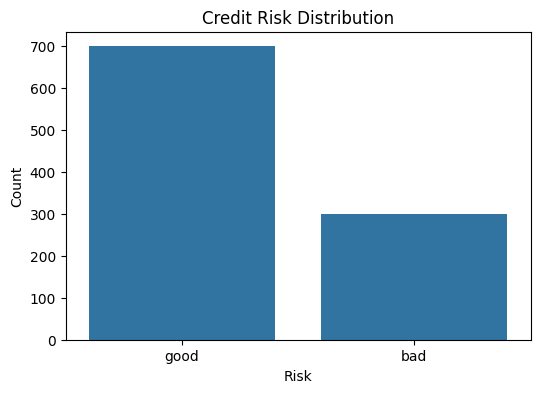

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Risk", data=df)

plt.title("Credit Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")

plt.show()

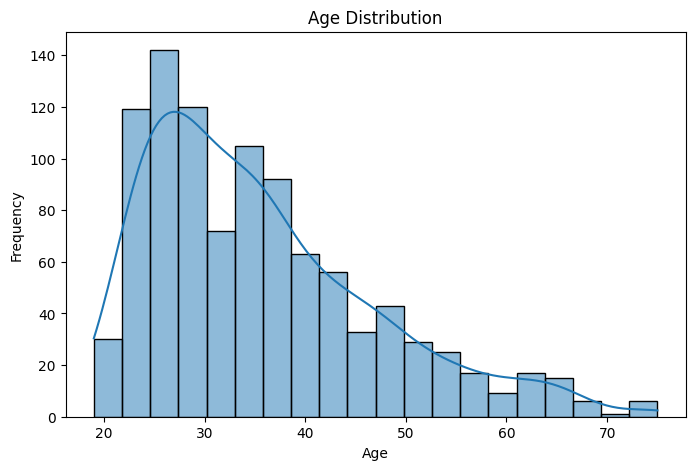

In [14]:
# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

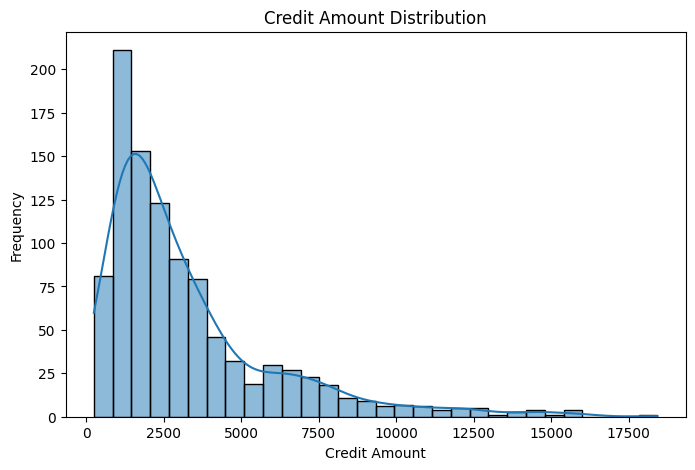

In [15]:
# Credit Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Credit amount"], bins=30, kde=True)

plt.title("Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")

plt.show()

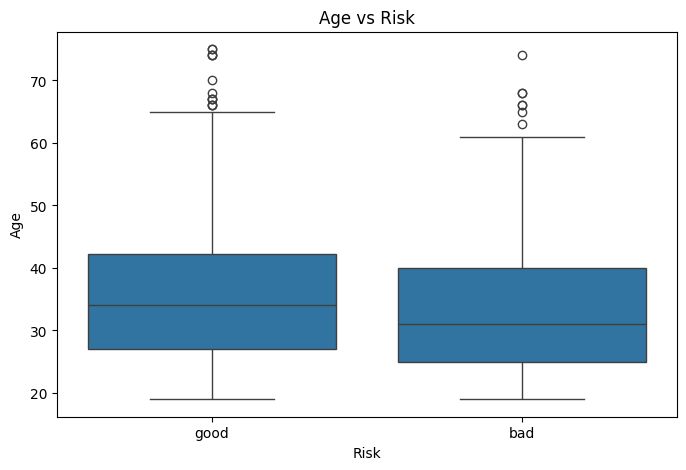

In [16]:
# Age vs Risk
plt.figure(figsize=(8,5))
sns.boxplot(x="Risk", y="Age", data=df)

plt.title("Age vs Risk")

plt.show()

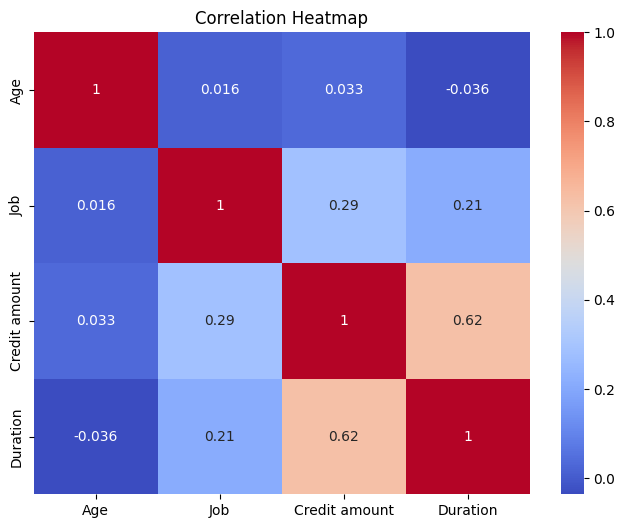

In [17]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

## 6. Data Preprocessing

In [18]:
# Check missing values

print(df.isnull().sum())

# Fill missing values with mode
df["Saving accounts"].fillna(df["Saving accounts"].mode()[0], inplace=True)
df["Checking account"].fillna(df["Checking account"].mode()[0], inplace=True)

# Check again
print("\nMissing Values After Filling:")
print(df.isnull().sum())

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Missing Values After Filling:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


In [19]:
# Encode Categorical Columns

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# List of categorical columns
cat_cols = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose", "Risk"]

# Apply Label Encoding
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Display first 5 rows
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,0,0,1169,6,5,1
1,22,0,2,1,0,1,5951,48,5,0
2,49,1,1,1,0,0,2096,12,3,1
3,45,1,2,0,0,0,7882,42,4,1
4,53,1,2,0,0,0,4870,24,1,0


In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   int64
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   int64
 4   Saving accounts   1000 non-null   int64
 5   Checking account  1000 non-null   int64
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   int64
 9   Risk              1000 non-null   int64
dtypes: int64(10)
memory usage: 78.3 KB
None


In [21]:
# Feature Selection

# Features (Independent Variables)
X = df.drop("Risk", axis=1)

# Target Variable (Dependent Variable)
y = df["Risk"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 9)
Target Shape: (1000,)


In [22]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (800, 9)
Testing Data : (200, 9)


In [23]:
# Feature Scaling:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


## 7. Logistic Regression

In [24]:
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression

# Create Model
lr_model = LogisticRegression(random_state=42)

# Train Model
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully!")

# Prediction
y_pred_lr = lr_model.predict(X_test_scaled)

# Probability Prediction
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

print("\n\nPrediction Completed!")

Logistic Regression Model Trained Successfully!


Prediction Completed!


In [25]:
# Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.665
Precision: 0.6972972972972973
Recall   : 0.9214285714285714
F1 Score : 0.7938461538461539
ROC AUC  : 0.6445238095238094


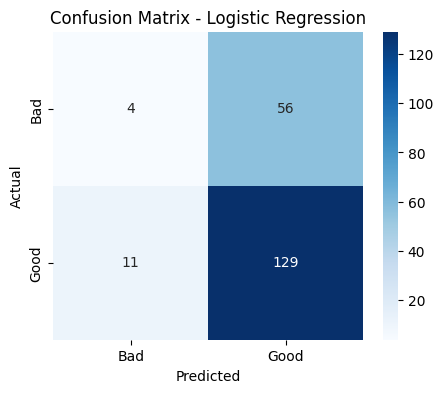

In [26]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Bad","Good"],
            yticklabels=["Bad","Good"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [27]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.27      0.07      0.11        60
           1       0.70      0.92      0.79       140

    accuracy                           0.67       200
   macro avg       0.48      0.49      0.45       200
weighted avg       0.57      0.67      0.59       200



## 8. Decision Tree

In [28]:
# Train Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Create Model
dt_model = DecisionTreeClassifier(random_state=42)

# Train Model
dt_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

# Prediction
y_pred_dt = dt_model.predict(X_test)

# Probability
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

print("\n\nPrediction Completed!")

Decision Tree Model Trained Successfully!


Prediction Completed!


In [29]:
# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt))

Accuracy : 0.605
Precision: 0.7226277372262774
Recall   : 0.7071428571428572
F1 Score : 0.7148014440433214
ROC AUC  : 0.536904761904762


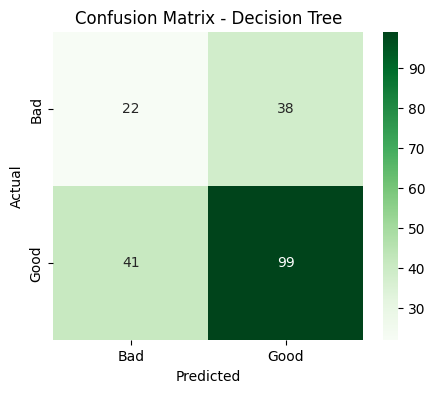

In [30]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens",
            xticklabels=["Bad","Good"],
            yticklabels=["Bad","Good"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [31]:
# Classification Report:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.35      0.37      0.36        60
           1       0.72      0.71      0.71       140

    accuracy                           0.60       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.61      0.60      0.61       200



## 9. Random Forest

In [32]:
# Random Forest:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Probability
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print("\n\nPrediction Completed!")

Random Forest Model Trained Successfully!


Prediction Completed!


In [33]:
# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.72
Precision: 0.7470588235294118
Recall   : 0.9071428571428571
F1 Score : 0.8193548387096774
ROC AUC  : 0.6689880952380953


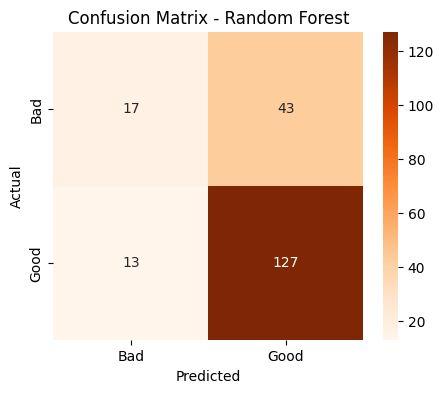

In [34]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Bad","Good"],
    yticklabels=["Bad","Good"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [35]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.57      0.28      0.38        60
           1       0.75      0.91      0.82       140

    accuracy                           0.72       200
   macro avg       0.66      0.60      0.60       200
weighted avg       0.69      0.72      0.69       200



## 10. Feature Importance

            Feature  Importance
6     Credit amount    0.302791
0               Age    0.209420
7          Duration    0.173102
8           Purpose    0.096987
2               Job    0.060925
5  Checking account    0.044586
3           Housing    0.042274
4   Saving accounts    0.038420
1               Sex    0.031494


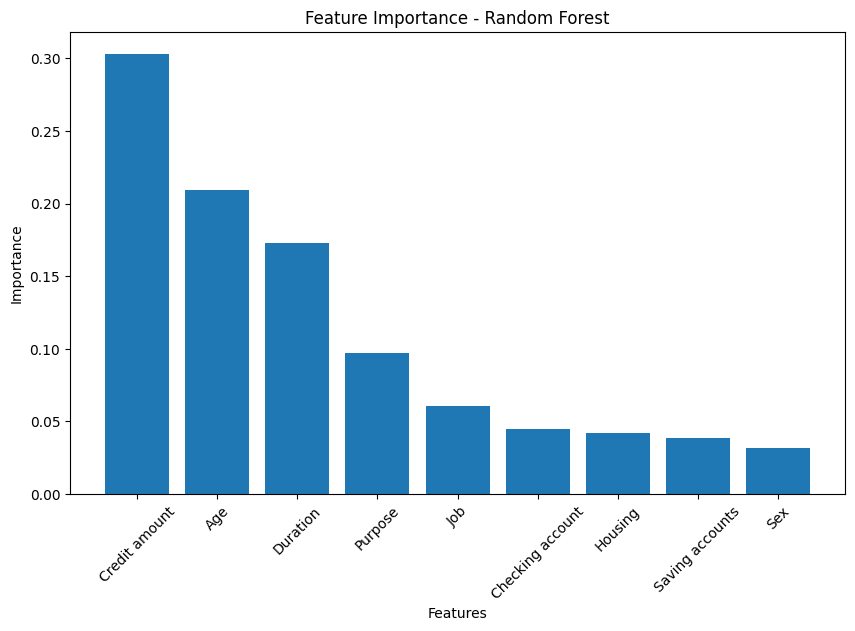

In [36]:
# Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

## 11. ROC Curve Comparison

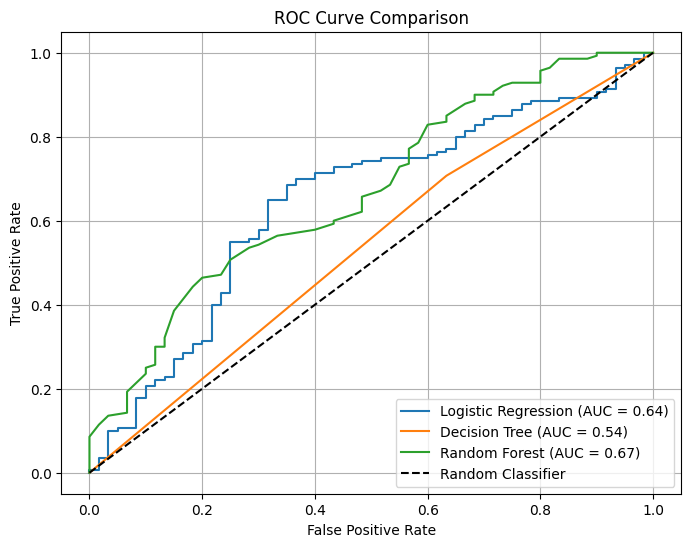

In [37]:
# ROC Curve Comparison
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC Curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# ROC Curve for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# ROC Curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")

# Random classifier line
plt.plot([0,1], [0,1], 'k--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

## 12. Model Comparison

                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression     0.665     0.6973  0.9214    0.7938   0.6445
1        Decision Tree     0.605     0.7226  0.7071    0.7148   0.5369
2        Random Forest     0.720     0.7471  0.9071    0.8194   0.6690





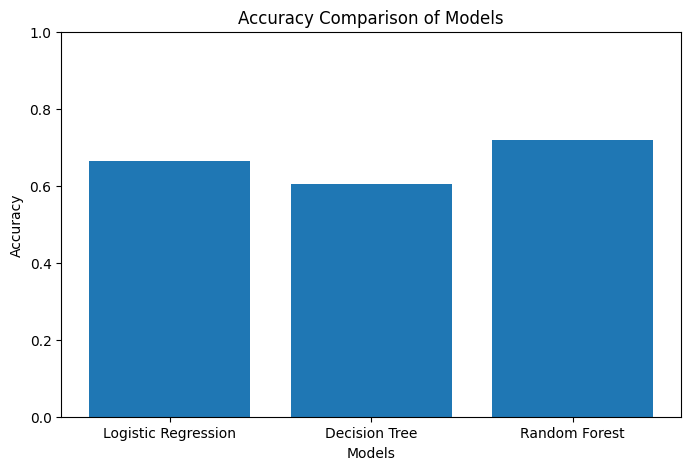

In [38]:
# Model Comparison Graph
import pandas as pd
import matplotlib.pyplot as plt

# Create comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [0.665, 0.605, 0.720],
    "Precision": [0.6973, 0.7226, 0.7471],
    "Recall": [0.9214, 0.7071, 0.9071],
    "F1 Score": [0.7938, 0.7148, 0.8194],
    "ROC AUC": [0.6445, 0.5369, 0.6690]
})

print(comparison)

# Accuracy Graph
print("\n\n")
plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

In [39]:
import joblib

joblib.dump(rf_model, "credit_scoring_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [40]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


##13. Feature Importance

The Random Forest model identified **Credit Amount**, **Age**, and **Duration** as the most important features for predicting customer credit risk. These variables had the greatest influence on the model's decision-making process, while **Sex** contributed the least.

#14. Conclusion

In this project, three machine learning algorithms—Logistic Regression, Decision Tree, and Random Forest—were used to predict customer credit risk.

After comparing all models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC, the Random Forest classifier achieved the best overall performance with:

- Accuracy: 72%
- Precision: 74.7%
- Recall: 90.7%
- F1-Score: 81.9%
- ROC-AUC: 66.9%

Therefore, Random Forest was selected as the final model for credit risk prediction because it provided the most balanced and reliable results.